In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import json
import argparse
import copy
import h5py
import torch

import warnings, os

from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

from scipy.ndimage import gaussian_filter

from map2points.utils.power import compute_power, compute_cylindrical_power

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)
hlittle = cosmo.H0.value / 100

from astropy import units as u

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def my_savefig(fsave):
    if fsave is not None:
        plt.tight_layout()
        plt.savefig(fsave, dpi=300)
        print("Saved figure to", fsave)

def load_data(fname, ix=0, iy=0, iz=0, nx=None, ny=None, nz=None, dataname="intensity0"):
    print("Load {} (data: {})".format(fname, dataname))
    with h5py.File(f"{fname}", "r") as f:
        intensity = f[dataname][:]
        header = {key: f.attrs[key] for key in f.attrs}

    if nx is None:
        nx = intensity.shape[0]
    if ny is None:
        ny = intensity.shape[1]
    if nz is None:
        nz = intensity.shape[2]
    intensity = intensity[ix:ix+nx, ix:ix+ny, ix:ix+nz]
    return intensity, header

def load_catalog_data(fname):
    print("Load catalog data from", fname)
    with h5py.File(fname, "r") as f:
        header = {key: f.attrs[key] for key in f.attrs}
        x_list = []
        #for key in ["SubhaloPos", "SubhaloVel", "SubhaloSFR", "SubhaloStellarMass"]:
        for key in ["SubhaloPos", "SubhaloSFR", "SubhaloStellarMass"]:
            x = f[key][:]
            if x.ndim == 1:
                x = x[:,None]
            if key == "SubhaloVel":
                x = x[:,-1:] # vz only
            x_list.append(x)
        
        cat = np.concatenate(x_list, axis=1)

    return cat, header

pos_idx = [0,1,2]
sfr_idx = 3
mstar_idx = 4

snapshot_number = 33
base_dir = "../data/mesh/generated_data"
stats_dir = "../data/mesh/generated_data/statistics"
output_dir = "../data/mesh/generated_data/figures"
os.makedirs(output_dir, exist_ok=True)

input_fname = "../data/mesh/TNG300-3-Dark/TNG300-3-Dark_dm_{:d}_keep0.10_npix256.h5".format(snapshot_number)
npix_orig = 256
npix_to_show = 128

with h5py.File(input_fname, "r") as f:
    density_map = f["density_map"][:] 

density_map = density_map[-npix_to_show:,-npix_to_show:,-npix_to_show:]

fpower_dm = "{}/power_dm_TNG300-3-Dark.txt".format(stats_dir)
if not os.path.exists(fpower_dm):
    boxsize = 205 * (npix_to_show / npix_orig)  # Mpc/h
    power_dm, k, var = compute_power(density_map / density_map.mean() - 1.0, boxlength=boxsize, log_bins=True)
    k = 0.5 * (k[1:] + k[:-1])

    with open(fpower_dm, "w") as f:
        for i in range(len(k)):
            f.write("{:e} {:e} {:e}\n".format(k[i], power_dm[i], var[i]))
    print("Saved DM power spectrum to", fpower_dm)

# Load data

In [2]:
### Load catalog 
nrea = 1
file_name_list_cat = [
    "../data/mesh/TNG300-1/TNG300-1_33.h5",
    "../data/mesh/TNG300-1/TNG300-1_33_for_comparison.h5",
]

gen_data_id_list = ["catalog.{:d}.threshold1.seed{:d}".format(snapshot_number, seed) for seed in range(nrea)]
file_name_list_cat += ["{}/{}.h5".format(base_dir, gen_data_id) for gen_data_id in gen_data_id_list]

labels = ["TNG", r"TNG ($M_{h} > 10^{12}~{\rm M_\odot}/h$)", "Generated", ] + ["Seed {:d}".format(i) for i in range(1,100)]
ls_list = ["-", "--"] + ["-"] * nrea

colors_black = [(0.8, 0.8, 0.8),(0.4, 0.4, 0.4),"black"]
colors_red = [(0.98, 0.8, 0.8),(0.9, 0.4, 0.4),"red"]
colors_blue = [(0.8, 0.86, 0.98), (0.4, 0.6, 0.9), "blue"]
#colors_list = [colors_black, colors_red, colors_blue]
#color_list = ["black", "red", "blue"]

colors_list = [colors_black, colors_black] + [colors_red] * nrea #, colors_blue]
color_list = ["black", "black"] + ["red"] * nrea #, "blue"] + ["blue"] * 100

cat_header_list = []
cat_list = []
for file_name in file_name_list_cat:
    cat, header = load_catalog_data(file_name)    

    if "TNG300-1_33.h5" in file_name or "TNG300-1_33_for_comparison.h5" in file_name:
        xmin = 205000 * (npix_orig - npix_to_show) / npix_orig
        mask = (cat[:,pos_idx[0]]>xmin) & (cat[:,pos_idx[1]] > xmin) & (cat[:,pos_idx[2]] > xmin)
        cat = cat[mask]
        cat[:,pos_idx] -= xmin
        header["BoxSize"] *= npix_to_show / npix_orig
    
        if "for_comparison" in file_name:
            with h5py.File(file_name, "r") as f:
                mass = f["SubhaloMass"][:]

            mass = mass[mask]

            print(len(cat))
            mask = mass > 1e12
            cat = cat[mask]
            print(len(cat))
    else:
        npix_to_use =  header["npix_to_use"]
        xmin = header["BoxSize"] * (npix_to_use - npix_to_show) / npix_to_use
        mask = (cat[:,pos_idx[0]]>xmin) & (cat[:,pos_idx[1]] > xmin) & (cat[:,pos_idx[2]] > xmin)
        cat = cat[mask]
        cat[:,pos_idx] -= xmin
        header["BoxSize"] *= npix_to_show / npix_to_use

    cat = np.random.permutation(cat)
    cat_list.append(cat)
    cat_header_list.append(header)

Load catalog data from ../data/mesh/TNG300-1/TNG300-1_33.h5
Load catalog data from ../data/mesh/TNG300-1/TNG300-1_33_for_comparison.h5
290447
2532
Load catalog data from ../data/mesh/generated_data/catalog.33.threshold1.seed0.h5


TNG: Ngal = 21481 
TNG ($M_{h} > 10^{12}~{\rm M_\odot}/h$): Ngal = 2339 
Generated: Ngal = 15069 
Saved figure to ../data/mesh/generated_data/figures/map.pdf


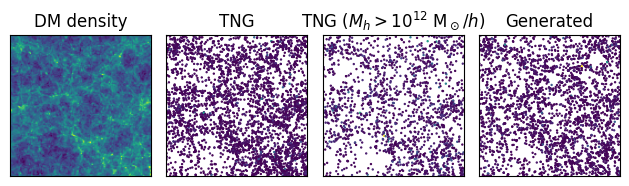

In [3]:
def plot_grid(ax, npix_patch=16, npix=npix_orig, boxsize=205e3, color="gray"):

    nline = npix // npix_patch
    dx = boxsize / npix

    grid = [ npix_patch * i * dx for i in range(nline) ]

    for x in grid:
        ax.vlines(x, ymin=ax.get_ylim()[0], ymax=ax.get_ylim()[1], linewidth=0.5, color=color)
        ax.hlines(x, xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], linewidth=0.5, color=color)

    plt.xlim(0, 50e3)
    plt.ylim(0, 50e3)

sfrmin = 10

nmap = 4
plt.figure()
plt.subplot(1,nmap, 1)
plt.title("DM density")
image = density_map.mean(axis=-1)
image = np.log10( image )
plt.imshow(image.T, origin="lower")
plt.xticks([])
plt.yticks([])

xmax = 205e3 / 2

for i in range(3):
    ax = plt.subplot(1, nmap, i+2)
    cat = cat_list[i]
    cat = cat[cat[:,sfr_idx] > sfrmin]
    ax.scatter(cat[:,pos_idx[0]], cat[:, pos_idx[1]], c=cat[:,sfr_idx], s=0.5)
    plt.title(labels[i])
    
    plt.xlim([0,xmax])
    plt.ylim([0,xmax])

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")

for i in range(len(cat_list)):
    print("{}: Ngal = {:d} ".format( labels[i], (cat_list[i][:,sfr_idx] > 1).sum()))

my_savefig("{}/map.pdf".format(output_dir))

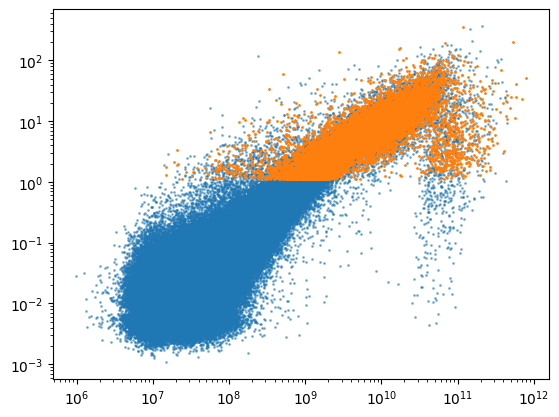

In [4]:
plt.scatter(cat_list[0][:,mstar_idx], cat_list[0][:,sfr_idx], s=1, alpha=0.5)
plt.scatter(cat_list[2][:,mstar_idx], cat_list[2][:,sfr_idx], s=1)

plt.yscale("log")
plt.xscale("log")

Saved figure to ../data/mesh/generated_data/figures/distribution_3d.pdf


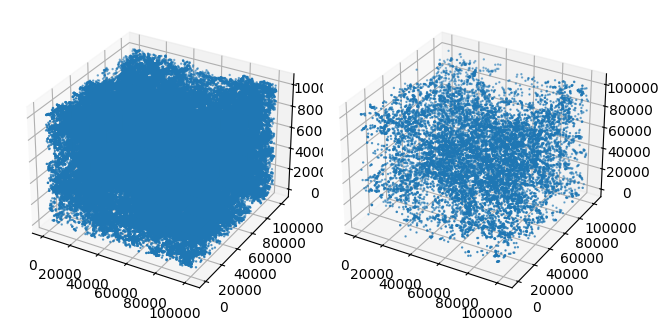

In [5]:

fig = plt.figure()
sfrmin = 10

ax = fig.add_subplot(121, projection="3d")
cat = cat_list[0]
cat[cat[:,sfr_idx] > sfrmin]
ax.scatter(cat[:,pos_idx[0]], cat[:,pos_idx[1]], cat[:,pos_idx[2]], s=0.5)

ax = fig.add_subplot(122, projection="3d")
cat = cat_list[2]
cat[cat[:,sfr_idx] > sfrmin]
ax.scatter(cat[:,pos_idx[0]], cat[:,pos_idx[1]], cat[:,pos_idx[2]], s=0.5)


my_savefig("{}/distribution_3d.pdf".format(output_dir))

2026-02-12 11:00:41.241 (   0.367s) [    7227AE94B480]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=localhost:11.0


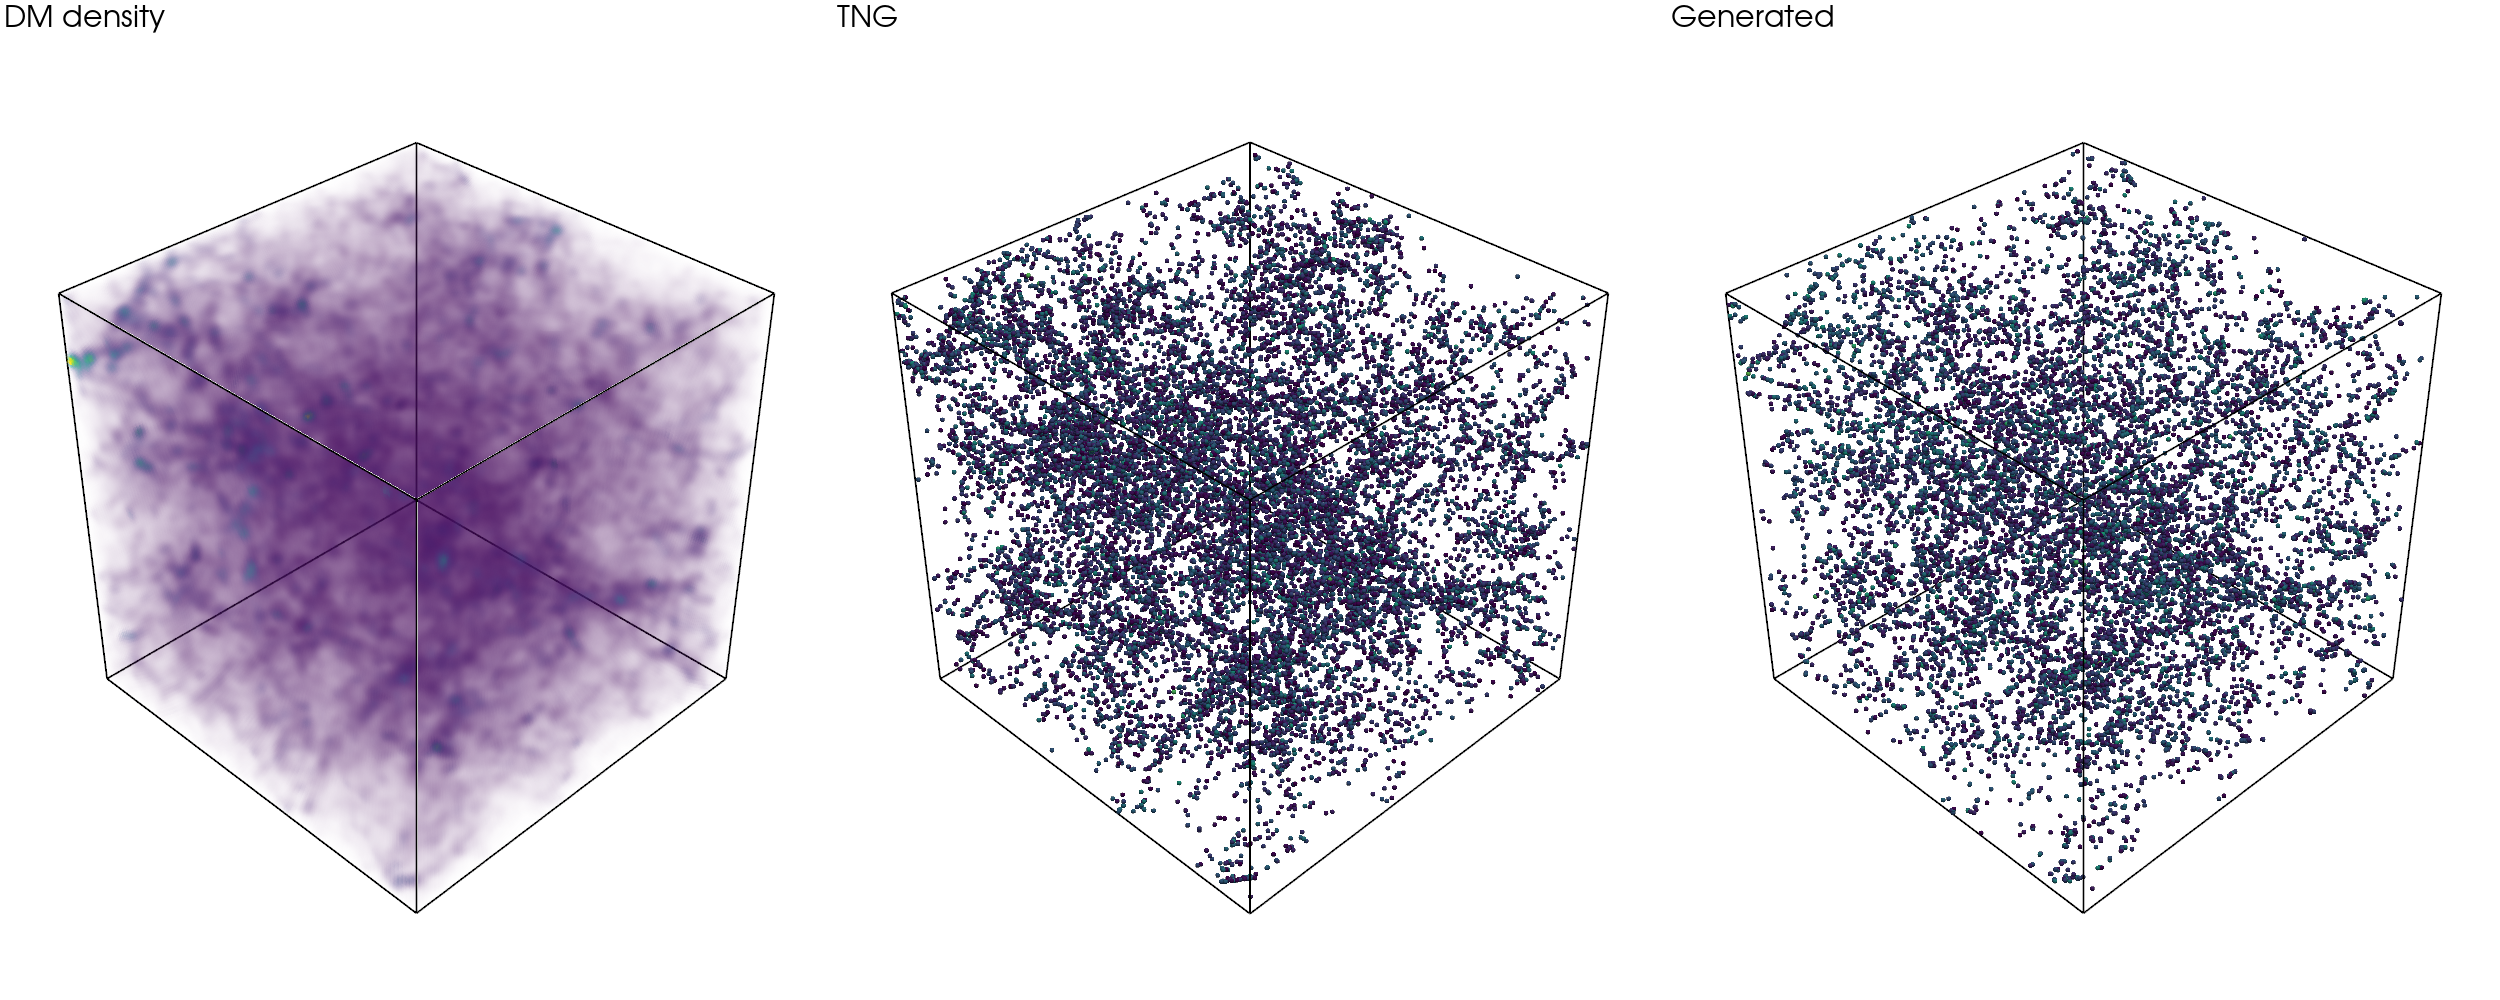

In [6]:
import pyvista as pv
import numpy as np
from scipy.ndimage import gaussian_filter
pv.set_jupyter_backend('static') 
        
opacity = "linear"
clim = None
cmap_points = None
use_point = True

data = gaussian_filter(density_map, sigma=1)

### show data
pixel_size = 1 / data.shape[0]
grid = pv.ImageData()
grid.origin = (0, 0, 0)
grid.spacing = (pixel_size, pixel_size, pixel_size)

if use_point:
    grid.dimensions = np.array(data.shape)
    grid.point_data["values"] = data.flatten(order="F")
else:
    grid.dimensions = np.array(data.shape) + 1
    grid.cell_data["values"] = data.flatten(order="F")

plotter = pv.Plotter(shape=(1, 3), border=False, window_size=(2500, 1000))

plotter.subplot(0, 0)
#plotter.camera.azimuth(10) 
plotter.add_volume(grid.copy(deep=True), cmap="viridis", show_scalar_bar=False, opacity=opacity, clim=clim)
plotter.add_text("DM density", font_size=12)
outline = grid.outline()
plotter.add_mesh(outline, color="black", line_width=2, style="wireframe")


def pv_plot_scatter(pos, color=None, boxsize=1, point_size=5, clim=[0,3]):
    point_cloud = pv.PolyData(pos[:,:3])
    point_cloud["scalars"] = np.log10(color)
    plotter.add_mesh(point_cloud, scalars="scalars", cmap="viridis", clim=clim, point_size=point_size, render_points_as_spheres=True, show_scalar_bar=False)
    bounds = (0, boxsize, 0, boxsize, 0, boxsize)
    box = pv.Box(bounds=bounds)
    plotter.add_mesh(box, color="black", line_width=2, style="wireframe")


plotter.subplot(0,1)
plotter.add_text(labels[0]+"       ", font_size=12)

cat_now = cat_list[0]
mask = cat_now[:,sfr_idx] > 1
cat_now = cat_now[mask]
boxsize = cat_header_list[0]["BoxSize"]

pv_plot_scatter(cat_now[:,pos_idx], cat_now[:,sfr_idx], boxsize=boxsize)


plotter.subplot(0,2)
plotter.add_text(labels[2], font_size=12)

cat_now = cat_list[2]
mask = cat_now[:,sfr_idx] > 1
cat_now = cat_now[mask]
boxsize = cat_header_list[2]["BoxSize"]
pv_plot_scatter(cat_now[:,pos_idx], cat_now[:,sfr_idx], boxsize=boxsize)

plotter.show()
### save screenshot
fsave="{}/volume.png".format(output_dir)
plotter.screenshot(fsave, return_img=False)


Saved figure to ../data/mesh/generated_data/figures/hist.pdf


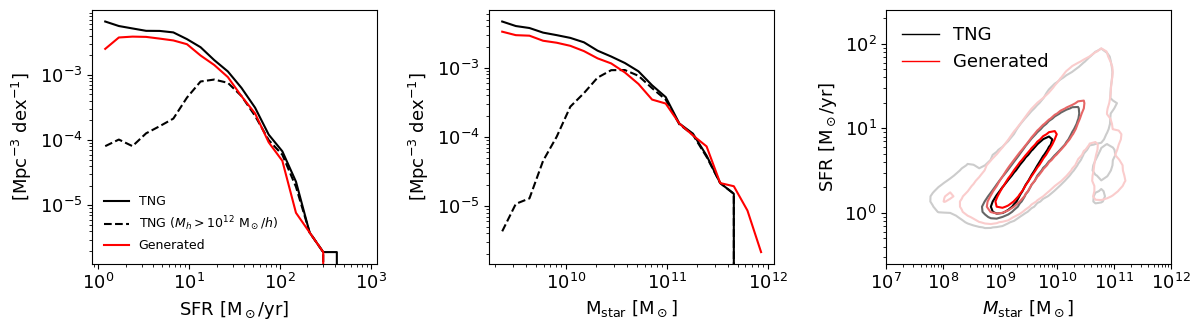

In [7]:
# Plot histograms
plt.rcParams["font.size"] = 13

def plot_hist(data, boxsize=None, range=(0,3), **kwargs):
    logv = np.log10(data + 1e-10)
    count, edges = np.histogram(logv, bins=20, range=range)
    if boxsize is not None:
        count = np.array(count) / (boxsize / hlittle) ** 3

    dlogx = edges[1:] - edges[:-1]
    count = count / dlogx
    plt.plot(10**(0.5*(edges[:-1]+edges[1:])), count, **kwargs)

plt.figure(figsize=(12,3.5))
plt.subplots_adjust(wspace=0.3)

ncat = nrea + 2

plt.subplot(1,3,1)
for i in range(ncat):
    header = cat_header_list[i] 
    boxsize = header.get("boxsize", header.get("BoxSize")) * 1e-3 # Mpc
    
    plot_hist(cat_list[i][:,sfr_idx], boxsize=boxsize, label=labels[i], ls=ls_list[i], color=colors_list[i][-1])

#plt.ylim(1e-6,2e-3)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\rm SFR\ [M_\odot/yr]$")
plt.ylabel(r"[Mpc$^{-3}$ dex$^{-1}$]")
plt.legend(frameon=False, fontsize=9)

plt.subplot(1,3,2)
for i in range(ncat):
    header = cat_header_list[i]
    boxsize = header.get("boxsize", header.get("BoxSize")) * 1e-3 # Mpc
    plot_hist(cat_list[i][:,mstar_idx], boxsize=boxsize, range=(9.3,12), label=labels[i], ls=ls_list[i], color=colors_list[i][-1])

#plt.ylim(1e-6,2e-3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\rm M_{\rm star}\ [M_\odot]$")
plt.ylabel(r"[Mpc$^{-3}$ dex$^{-1}$]")

#plt.legend(frameon=False)

from plot_utils import plot_contour

plt.subplot(1,3,3)

handles = []
for i, cat in enumerate(cat_list[:3]):
    
    if i == 1:
        continue

    x = cat[:,mstar_idx] 
    xlim = [1e7,1e12]

    y = cat[:,sfr_idx]
    ylim = [10**(-0.6), 10**(2.4)]

    mask = ( y > 1 ) & ( x > 0 )
    x = x[mask]
    y = y[mask]

    line = plot_contour(x, y, colors_list[i], xlim=xlim, ylim=ylim, label=labels[i], logscale=True)
    #plt.scatter(x, y, label=labels[i])
    handles.append(line)

plt.legend(handles=handles, frameon=False, loc="upper left")

#plt.xlabel(r"$v_z$ [km/s]")
plt.xlabel(r"$M_{\rm star} \ \rm [M_\odot]$")
plt.ylabel(r"SFR $ \rm [M_\odot/yr]$")
#plt.ylim(1e0, 3e2)
plt.xscale("log")
plt.yscale("log")

my_savefig("{}/hist.pdf".format(output_dir))

# Correlation function

output: ../data/mesh/generated_data/figures/xi_TNG_sfrmin1.txt
output: ../data/mesh/generated_data/figures/xi_Generated_sfrmin1.txt
Saved figure to ../data/mesh/generated_data/figures/xi.pdf


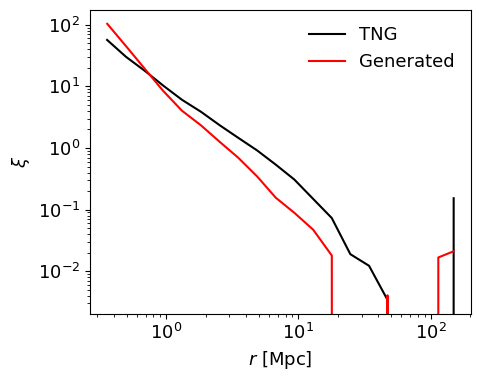

In [8]:
from cosmoglint.utils.stats import calc_corr

sfrmin = 1

boxsize = cat_header_list[0]["BoxSize"]

plt.figure(figsize=(5,4.))
for i_cat, cat in enumerate(cat_list[:3]):
    if i_cat == 1:
        continue
    sfr = cat[:,sfr_idx]
    mstar = cat[:, mstar_idx]

    mask = (sfr > sfrmin)
    r, xi, varxi = calc_corr(cat[mask] / 1e3, boxsize /1e3, n_random=10*len(cat), fout="{}/xi_{}_sfrmin{}.txt".format(output_dir, labels[i_cat], str(sfrmin)))
    plt.plot(r, xi, label=labels[i_cat], color=color_list[i_cat], ls=ls_list[i_cat])
    #plt.errorbar(r, xi, np.sqrt(varxi), fmt=".", label=labels[i_cat])

plt.xlabel(r"$r$ [Mpc]")
plt.ylabel(r"$\xi$")
plt.xscale("log")
plt.yscale("log")
plt.legend(frameon=False)
my_savefig("{}/xi.pdf".format(output_dir))

# Radial profile

In [9]:
import numpy as np
from cosmoglint.utils.stats import radial_profile_around_points

r_min = 3.0
r_max = 50.0  
nbins = 20

profiles_list = []
radii_list = []
fout_list = [
    "{}/radial_profile_TNG.txt".format(stats_dir), 
    None,
    "{}/radial_profile.txt".format(stats_dir)
]

for i_cat in range(3):
    if i_cat == 1:
        continue

    if os.path.exists(fout_list[i_cat]):
        print("{} exists. Skip".format(fout_list[i_cat]))
        continue

    cat = cat_list[i_cat]
    mask = cat[:, sfr_idx] > 1
    cat = cat[mask]
    pos = cat[:,:3] / 1e3

    header = cat_header_list[i_cat]   
    boxsize = header.get("boxsize", header.get("BoxSize")) / 1e3

    profiles, radii = radial_profile_around_points(density_map, pos, r_min, r_max, nbins, voxel_size=boxsize/npix_to_show)
    profiles_list.append(profiles)
    radii_list.append(radii)

    print("radii shape:", radii.shape)        # (nbins,)
    print("profiles shape:", profiles.shape)  # (L, nbins)
    print(profiles[0])

    # Print out
    mask = ~np.isnan(profiles).any(axis=1)
    p = profiles[mask]
    p_mean = p.mean(axis=0)
    p_var = p.var(axis=0)
    with open(fout_list[i_cat], "w") as f:
        for i in range(len(radii)):
            f.write("{:e} {:e} {:e}\n".format(radii[i], p_mean[i], p_var[i]))

    print("Output {}".format(fout_list[i_cat]))

radii shape: (20,)
profiles shape: (21481, 20)
[176.1892512  145.28027919 173.64010123 125.43586663 149.73773045
 197.52206715 118.01111577 112.71847996 103.71426659  78.00557795
 101.20553916  91.34189258  81.87013579  81.06237954  70.14208507
  73.13653169  70.79712431  71.61976038  72.45795434  81.27648843]
Output ../data/mesh/generated_data/statistics/radial_profile_TNG.txt
radii shape: (20,)
profiles shape: (15069, 20)
[ 76.945817   101.57364326 131.19870056 103.37246958  91.84166477
 103.5201492  101.51646724 108.25404066 114.72028362  98.51869999
  85.12525175  87.80926044  83.04376096  75.96434349  74.72292612
  79.02139565  83.24373736  87.10353285  87.69003831  80.39432488]
Output ../data/mesh/generated_data/statistics/radial_profile.txt


Saved figure to ../dataset/generated_data/figures/radial_profile.pdf


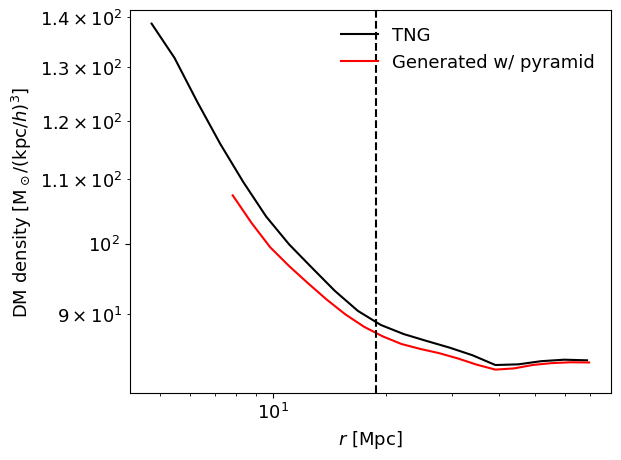

In [ ]:
run_name1 = "ddpm_quadratic_crossformer_33_npix16_ep6000_hd128_nl4_nlcond3_nlpyr3_w0.01_lr1e-4_pad_with_flag"
run_name2 = "ddpm_quadratic_crossformer_33_npix16_ep6000_hd128_nl4_nlcond3_nlpyr0_w0.01_lr1e-4_pad_with_flag"

sfrmin = 1
stats_dir = "../data/generated_data/statistics"
fname_list = ["{}/r_profile_sfrmin{}_TNG.txt".format(stats_dir, str(sfrmin)), 
              "{}/r_profile_sfrmin{}_{}_seed0.txt".format(stats_dir, str(sfrmin), run_name),
             #"{}/r_profile_{}.txt".format(stats_dir, run_name1),
             #"{}/r_profile_{}.txt".format(stats_dir, run_name2)
]

c_list_now = ["k"] + ["r"] * 100
ls_list_now = ["-", "-"] + ["-."] * 100
l_list_now = ["TNG", "Generated w/ pyramid", "Generated w/o pyramid", ""]
for i, fname in enumerate(fname_list):
    data = np.loadtxt(fname)
    r = data[:,0] / hlittle
    p_mean = data[:,1]
    p_var = data[:,2]
    plt.plot(r, p_mean, color=c_list_now[i], ls=ls_list_now[i], label=l_list_now[i])

ylim = plt.ylim()
l_patch = 16 * 1.18
plt.vlines(l_patch, ylim[0], ylim[1], ls="--", color="k")
plt.ylim(ylim)

plt.yscale("log")
plt.xscale("log")
plt.ylabel(r"DM density [${\rm M_\odot /(kpc}/h)^{3}$]")
plt.xlabel(r"$r\ [\rm Mpc]$")
plt.legend(frameon=False)
my_savefig("{}/radial_profile.pdf".format(output_dir))

# Number density map

In [10]:
sfrmin = 10
from cosmoglint.utils import make_density_map

for i_cat, cat in enumerate(cat_list[:3]):
    if i_cat == 0:
        fout = "{}/power_sfrmin{}_TNG.txt".format(stats_dir, str(sfrmin))
        fout_cross = "{}/cross_power_sfrmin{}_TNG.txt".format(stats_dir, str(sfrmin))
    elif i_cat == 1:
        continue
    else:
        fout = "{}/power_sfrmin{}_seed{:d}.txt".format(stats_dir, str(sfrmin), i_cat - 2)
        fout_cross = "{}/cross_power_sfrmin{}_seed{:d}.txt".format(stats_dir, str(sfrmin), i_cat - 2)

    if os.path.exists(fout):
        print("{} exists. Skip".format(fout))
        continue

    boxsize = cat_header_list[i_cat].get("boxsize", cat_header_list[i_cat].get("BoxSize")) / 1e3
    dx = boxsize / npix_to_show

    mask = cat[:,sfr_idx] > sfrmin
    cat = cat[mask]

    pos = cat[:, :3] / 1e3

    nden = make_density_map(pos / dx, npix=npix_to_show, mode="CIC")

    delta_nden = nden / nden.mean() - 1.0 # delta

    power, k, var = compute_power(delta_nden, boxlength=boxsize, log_bins=True)

    k_values = 0.5 * (k[1:] + k[:-1])
    
    power_shot = np.ones_like(k_values) * boxsize**3 / nden.sum()
    print(power_shot[0])

    with open(fout, "w") as f:
        for i in range(len(k_values)):
            f.write("{:e} {:e} {:e} {:e}\n".format(k_values[i], power[i], var[i], power_shot[i]))
    print("Saved power spectrum to", fout)

    power, k, var = compute_power(delta_nden, density_map / density_map.mean() - 1.0, boxlength=boxsize, log_bins=True)

    k_values = 0.5 * (k[1:] + k[:-1])

    with open(fout_cross, "w") as f:
        for i in range(len(k_values)):
            f.write("{:e} {:e} {:e} {:e}\n".format(k_values[i], power[i], var[i], power_shot[i]))
    print("Saved power spectrum to", fout)
    

269.55960575719666
Saved power spectrum to ../data/mesh/generated_data/statistics/power_sfrmin10_TNG.txt


power.py:83: RuntimeWarning: invalid value encountered in divide


Saved power spectrum to ../data/mesh/generated_data/statistics/power_sfrmin10_TNG.txt
338.6448506289308
Saved power spectrum to ../data/mesh/generated_data/statistics/power_sfrmin10_seed0.txt


power.py:83: RuntimeWarning: invalid value encountered in divide
power.py:83: RuntimeWarning: invalid value encountered in divide


Saved power spectrum to ../data/mesh/generated_data/statistics/power_sfrmin10_seed0.txt


power.py:83: RuntimeWarning: invalid value encountered in divide


../dataset/generated_data_mesh/statistics/power_sfrmin10.0_TNG.txt
../dataset/generated_data_mesh/statistics/power_sfrmin10.0_catalog.33.threshold1.seed0.txt
../dataset/generated_data_mesh/statistics/cross_power_sfrmin10.0_TNG.txt
../dataset/generated_data_mesh/statistics/cross_power_sfrmin10.0_catalog.33.threshold1.seed0.txt


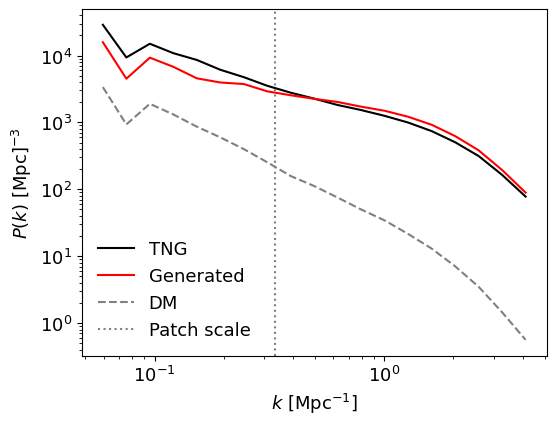

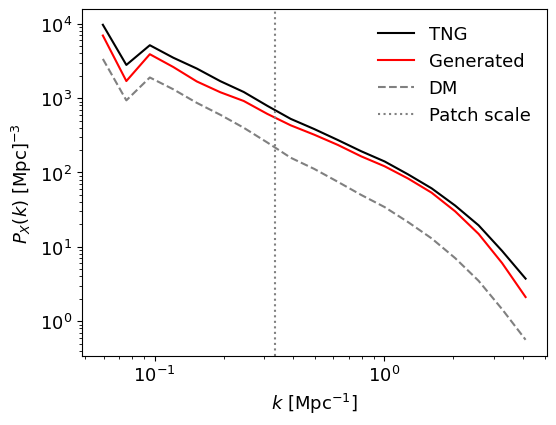

In [7]:
sfrmin = 1.0
sfrmin = 10.0
with_hlittle = False
pixel_size = 1.18 # [Mpc]
patch_size = 16 * pixel_size  # [Mpc]

for p in ["power", "cross_power"]:

    plt.figure(figsize=(6,4.5))
    for i_cat, cat in enumerate(cat_list[:3]):
        if i_cat == 0:
            fout = "{}/{}_sfrmin{}_TNG.txt".format(stats_dir, p, str(sfrmin))
        elif i_cat == 1:
            continue
        else:
            #fout = "{}/{}_sfrmin{}_{}_seed{:d}.txt".format(stats_dir, p, str(sfrmin), run_name, i_cat - 2)
            fout = "{}/{}_sfrmin{}_{}.txt".format(stats_dir, p, str(sfrmin), gen_data_id_list[i_cat - 2])
        print(fout)
        data = np.loadtxt(fout)
        k = data[:,0]
        power = data[:,1]

        if not with_hlittle:
            k = k * hlittle
            power = power / hlittle**3
            

        if p == "cross_power":
            plt.plot(k, power, label=labels[i_cat], color=color_list[i_cat], ls=ls_list[i_cat])
        else:
            plt.plot(k, power, label=labels[i_cat], color=color_list[i_cat], ls=ls_list[i_cat], alpha=1)
            label_clust = "Clustering" if i_cat == 0 else None
            label_shot = "Shot noise" if i_cat == 0 else None
            power_shot = data[:,3]
            if not with_hlittle:
                power_shot = power_shot / hlittle**3
            #plt.plot(k, power - power_shot, color=color_list[i_cat], ls=ls_list[i_cat], alpha=0.5, label=label_clust)
            #plt.plot(k, power_shot, color=color_list[i_cat], ls=ls_list[i_cat], alpha=0.5, label=label_shot)
            
    
    fpower_dm = "{}/power_dm_TNG300-3-Dark.txt".format(stats_dir)
    data = np.loadtxt(fpower_dm)
    k = data[:,0]
    power_dm = data[:,1]

    if not with_hlittle:
        k = k * hlittle
        power_dm = power_dm / hlittle**3

    plt.plot(k, power_dm, label="DM", color="gray", ls="--")

    #fpower_dm = "{}/power_dm_TNG300-1-Dark.txt".format(output_dir)
    #data = np.loadtxt(fpower_dm)
    #k = data[:,0]
    #power_dm = data[:,1]
    #plt.plot(k, power_dm, label="DM (TNG300-1-Dark)", color="gray", ls=":")

    if with_hlittle:
        plt.xlabel(r"$k \ [h \ \rm Mpc^{-1}]$")
    else:
        plt.xlabel(r"$k \ [\rm Mpc^{-1}]$")

    if p == "cross_power":
        if with_hlittle:
            plt.ylabel(r"$P_X(k)\ [{\rm Mpc}/h]^{-3}$")
        else:
            plt.ylabel(r"$P_X(k)\ [{\rm Mpc}]^{-3}$")
    else:
        if with_hlittle:
            plt.ylabel(r"$P(k)\ [{\rm Mpc}/h]^{-3}$")
        else:
            plt.ylabel(r"$P(k)\ [{\rm Mpc}]^{-3}$")

    plt.xscale("log")
    plt.yscale("log")
    ylim = plt.ylim()

    plt.vlines(2 * np.pi / patch_size, ymin=ylim[0], ymax=ylim[1], color="gray", ls=":", label="Patch scale")
    plt.ylim(ylim)

    plt.legend(frameon=False)

# Intensity map

In [ ]:
from cosmoglint.utils import make_density_map

sfrmin = 1

data_list = []
for i_cat, cat in enumerate(cat_list):

    boxsize = cat_header_list[i_cat].get("boxsize", cat_header_list[i_cat].get("BoxSize")) / 1e3
    dx = boxsize / npix_to_show

    intensity = np.zeros((npix_to_show, npix_to_show, npix_to_show))

    mask = cat[:,sfr_idx] > sfrmin
    cat = cat[mask]

    pos = cat[:, :3] / 1e3
    
    intensity = make_density_map(pos / dx, npix_to_show, weight=cat[:,sfr_idx], mode="CIC")
    data_list.append(intensity)

In [6]:
def show_images(data_list, titles, fsave=None, vmin=None, vmax=None, norm=None, xmin=0, ymin=0, zmin=0, nx=-1, ny=-1, nz=-1, sigma=1):

    plt.figure(figsize=(len(data_list) * 3 + 3, 3))
    nmap = len(data_list) + 1
    
    plt.subplot(1, nmap, 1)
    plt.title("Input")
    image = density_map.mean(axis=1)
    image = np.log10( image )
    plt.imshow(image.T, origin="lower")
    plt.xticks([])
    plt.yticks([])

    for i, d in enumerate(data_list):        
        image = d[xmin:xmin+nx, ymin:ymin+ny, zmin:zmin+nz].sum(axis=1)
        image = gaussian_filter(image, sigma=sigma)
        
        plt.subplot(1, nmap, i+2)
        plt.title(titles[i])
        plt.imshow(image.T, origin="lower", interpolation="none", vmin=vmin, vmax=vmax, norm=norm)

        plt.xticks([])
        plt.yticks([])
        
        if vmin is None or vmax is None:
            plt.colorbar()

        print(image.min(), image.max())
        
    my_savefig(fsave)
        
fsave = "{}/intensity_maps.pdf".format(output_dir)

show_images(data_list, labels, fsave=fsave, vmin=0, vmax=100)
#show_images(fname_list, titles, fsave, norm=LogNorm(vmin=0.1, vmax=100))


NameError: name 'data_list' is not defined

1


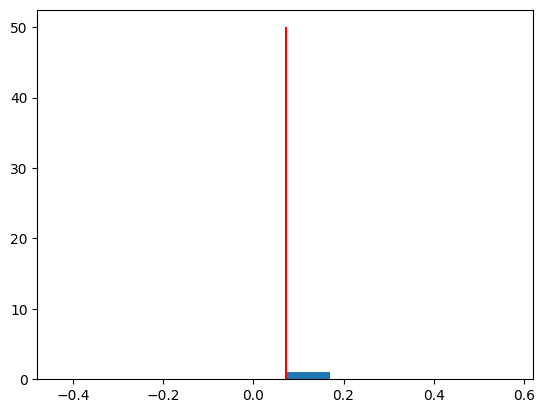

In [11]:
true_mean = data_list[0].mean()
mean_intensity = np.array(data_list[2:]).mean(axis=(1,2,3))
print(len(data_list[2:]))
plt.figure()
plt.hist(mean_intensity)
plt.vlines(true_mean, ymin=0, ymax=50, color="red", label="True mean")

In [8]:
def show_power(data_list, titles, fsave=None, vmin=None, vmax=None, norm=None, xmin=0, ymin=0, zmin=0, nx=-1, ny=-1, nz=-1, sigma=2):

    plt.figure(figsize=(len(data_list) * 3, 3))
    for i, d in enumerate(data_list):
        image = d[xmin:xmin+nx, ymin:ymin+ny, zmin:zmin+nz].sum(axis=0)
        
        fft2 = np.fft.fft2(image)
        fft2_shift = np.fft.fftshift(fft2)
        power2d = np.abs(fft2_shift)**2

        power2d = gaussian_filter(power2d, sigma=2)

        plt.subplot(1, len(data_list), i+1)
        plt.title(titles[i])
        
        plt.imshow(np.log10(power2d), vmin=vmin, vmax=vmax)
        plt.xticks([])
        plt.yticks([])
        plt.colorbar()
        
    my_savefig(fsave)
        
fsave = "{}/power.pdf".format(output_dir)
show_power(data_list[:3], ["TNG", "Generated", "Generated (Round 0 only)"], fsave=fsave, vmin=5.2, vmax=7)
#show_images(fname_list, titles, fsave, norm=LogNorm(vmin=0.1, vmax=100))

NameError: name 'data_list' is not defined

In [ ]:
with_hlittle = False
pixel_size = 1.18 # [Mpc]
patch_size = 16 * pixel_size  # [Mpc]

for p in ["lim_power", "lim_cross_power"]:

    plt.figure(figsize=(6,4.5))
    for i_cat in range(len(cat_list)):
        if i_cat == 1:
            continue
        
        if i_cat == 0:
            #fout = "{}/{}_TNG.txt".format(output_dir, p)
            fout = "{}/{}_sfrmin{}_TNG.txt".format(output_dir, p, str(sfrmin))
        else:
            fout = "{}/{}_sfrmin{}_{}_seed{:d}.txt".format(output_dir, p, str(sfrmin), run_name, i_cat - 2)

        if not os.path.exists(fout):
            boxsize = cat_header_list[i_cat].get("boxsize", cat_header_list[i_cat].get("BoxSize")) / 1e3
            dx = boxsize / npix_to_show

            if "cross" in p:
                power, k, var = compute_power(data_list[i_cat], density_map / density_map.mean() - 1.0, boxlength=boxsize, log_bins=True)
            else:
                power, k, var = compute_power(data_list[i_cat], boxlength=boxsize, log_bins=True)
        
            k = 0.5 * (k[1:] + k[:-1])
            
            power_shot = np.ones_like(k) * (cat_list[i_cat][:,sfr_idx]**2).mean() #boxsize**3 / nden.sum()
            print(power_shot[0])

            with open(fout, "w") as f:
                for i in range(len(k)):
                    f.write("{:e} {:e} {:e} {:e}\n".format(k[i], power[i], var[i], power_shot[i]))
            print("Saved power spectrum to", fout)

        else:
                
            data = np.loadtxt(fout)
            k = data[:,0]
            power = data[:,1]
            power_shot = data[:,3]

        if not with_hlittle:
            k = k * hlittle
            power = power / hlittle**3
            power_shot = power_shot / hlittle**3

        alpha = 1 if i_cat == 0 else 0.2
        if len(cat_list) < 5:
            alpha = 1
        plt.plot(k, power, label=labels[i_cat], color=color_list[i_cat], ls=ls_list[i_cat], zorder=-i_cat, alpha=alpha)
        plt.plot(k, power_shot, color=color_list[i_cat], ls=ls_list[i_cat], alpha=0.01)

    fpower_dm = "{}/power_dm_TNG300-3-Dark.txt".format(output_dir)
    data = np.loadtxt(fpower_dm)
    k = data[:,0]
    power_dm = data[:,1]
    if not with_hlittle:
        k = k * hlittle
        power_dm = power_dm / hlittle**3
        
    plt.plot(k, power_dm, label="DM", color="gray", ls="--")


    if with_hlittle:
        plt.xlabel(r"$k \ [h \ \rm Mpc^{-1}]$")
    else:
        plt.xlabel(r"$k \ [\rm Mpc^{-1}]$")

    if p == "cross_power":
        if with_hlittle:
            plt.ylabel(r"$P_X(k)\ [{\rm Mpc}/h]^{-3}$")
        else:
            plt.ylabel(r"$P_X(k)\ [{\rm Mpc}]^{-3}$")
    else:
        if with_hlittle:
            plt.ylabel(r"$P(k)\ [{\rm Mpc}/h]^{-3}$")
        else:
            plt.ylabel(r"$P(k)\ [{\rm Mpc}]^{-3}$")

    plt.xscale("log")
    plt.yscale("log")
    ylim = plt.ylim()

    plt.vlines(2 * np.pi / patch_size, ymin=ylim[0], ymax=ylim[1], color="gray", ls=":", label="Patch scale")
    plt.ylim(ylim)

    plt.legend(frameon=False)


NameError: name 'data_list' is not defined

<Figure size 600x450 with 0 Axes>

# Contribution to total intensity

Saved figure to ../dataset/generated_data/figures/fraction.pdf


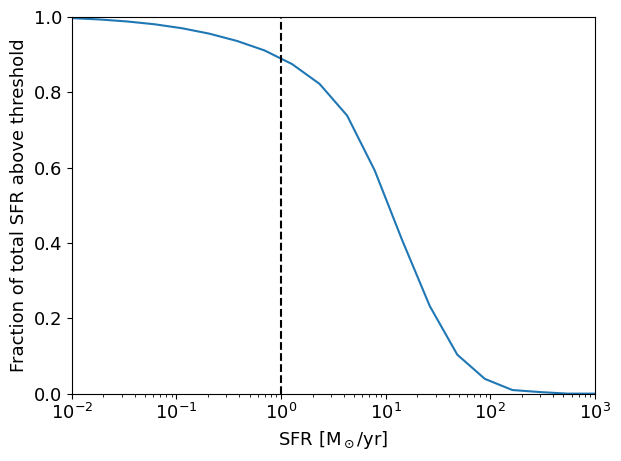

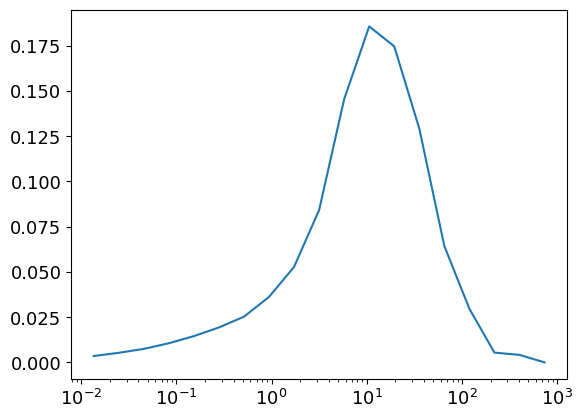

In [ ]:
cat = cat_list[0]
sfr = cat[:,sfr_idx]
thresholds = np.logspace(-2,3,20)

fractions = []
total_sfr = sfr.sum()
for th in thresholds:
    mask = sfr > th
    fractions.append( sfr[mask].sum() / total_sfr )
fractions = np.array(fractions)

plt.figure()
plt.plot(thresholds, fractions)
plt.vlines(1, 0, 1, ls="--", color="k")
plt.xlim(thresholds[0], thresholds[-1])
plt.ylim(0,1)
plt.xscale("log")
plt.xlabel(r"SFR [$\rm M_\odot/yr$]")
plt.ylabel("Fraction of total SFR above threshold")
my_savefig("{}/fraction.pdf".format(output_dir))

plt.figure()
x = 10 ** (0.5 * (np.log10(thresholds[1:]) + np.log10(thresholds[:-1])))
y = fractions[:-1] - fractions[1:]
plt.plot(x, y)
plt.xscale("log")


# Count the number of galaxies per voxel

Load catalog data from ../dataset/TNG300-1/TNG300-1_33.h5
Npix (patch) 256
Npix (whole box):  4096
pixel size: 0.050 Mpc
Maximum patch size: 3.203 Mpc
Total number of pixels: 134217728 (512**3)
Ratio of no-galaxy pixels:  0.9999985173344612
Total number of pixels: 134217728 (512**3)
Ratio of no-galaxy pixels:  0.9999997615814209
Total number of pixels: 134217728 (512**3)
Ratio of no-galaxy pixels:  1.0
Saved figure to ../dataset/generated_data/figures/num_gal_per_voxel.pdf


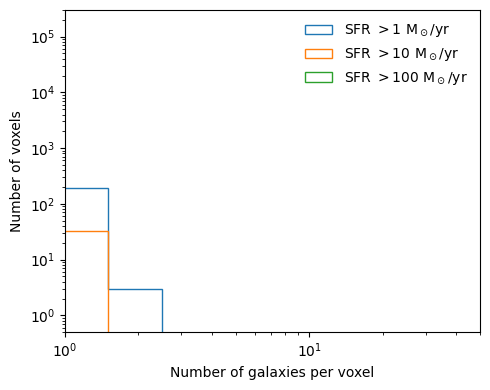

In [ ]:
fname = "../dataset/TNG300-1/TNG300-1_33.h5"
cat, header = load_catalog_data(fname)        

boxsize = header["BoxSize"]

_npix = 512
dx = boxsize / _npix

factor = 8
dx = dx / factor

patch_size_max = dx * 64

print("Npix (patch)", 32 * factor)
print("Npix (whole box): ", _npix * factor)

print("pixel size: {:.3f} Mpc".format(dx/1e3))
print("Maximum patch size: {:.3f} Mpc".format(dx * 64/1e3))


volume = (boxsize * 1e-3) ** 3

plt.figure(figsize=(5,4))

for sfrmin in [1, 10, 100]:
    mask = cat[:,sfr_idx] > sfrmin
    cat = cat[mask]
    pos = cat[:,pos_idx]
    ix = (pos / dx).astype(int)
    valid_mask = np.all((ix >=0) & (ix < _npix), axis=1)
    ix = ix[valid_mask]
    nden = np.zeros((_npix, _npix, _npix))
    np.add.at(nden, (ix[:,0], ix[:,1], ix[:,2]), 1)
    data = nden.reshape(-1)
    hist = plt.hist(data, bins=np.arange(-0.5,101.5,1), histtype="step", label=r"SFR $> %.0f\ \rm M_\odot/yr$" % sfrmin, align="mid") #, weights=1./volume * np.ones_like(data), )

    print("Total number of pixels: {:.0f} ({:.0f}**3)".format(hist[0].sum(), hist[0].sum() ** (1/3)))
    print("Ratio of no-galaxy pixels: ", hist[0][0] / hist[0].sum())

plt.yscale("log")
plt.xscale("log")
plt.xlim(1,50)
plt.ylim(0.5, 3e5)
#plt.grid()
plt.legend(frameon=False)
plt.xlabel("Number of galaxies per voxel")
plt.ylabel("Number of voxels")
#plt.ylabel(r"Number density of voxels [Mpc$^{-3}$]")
my_savefig("{}/num_gal_per_voxel.pdf".format(output_dir))